In [1]:
import pandas as pd
import matplotlib.pyplot as plt


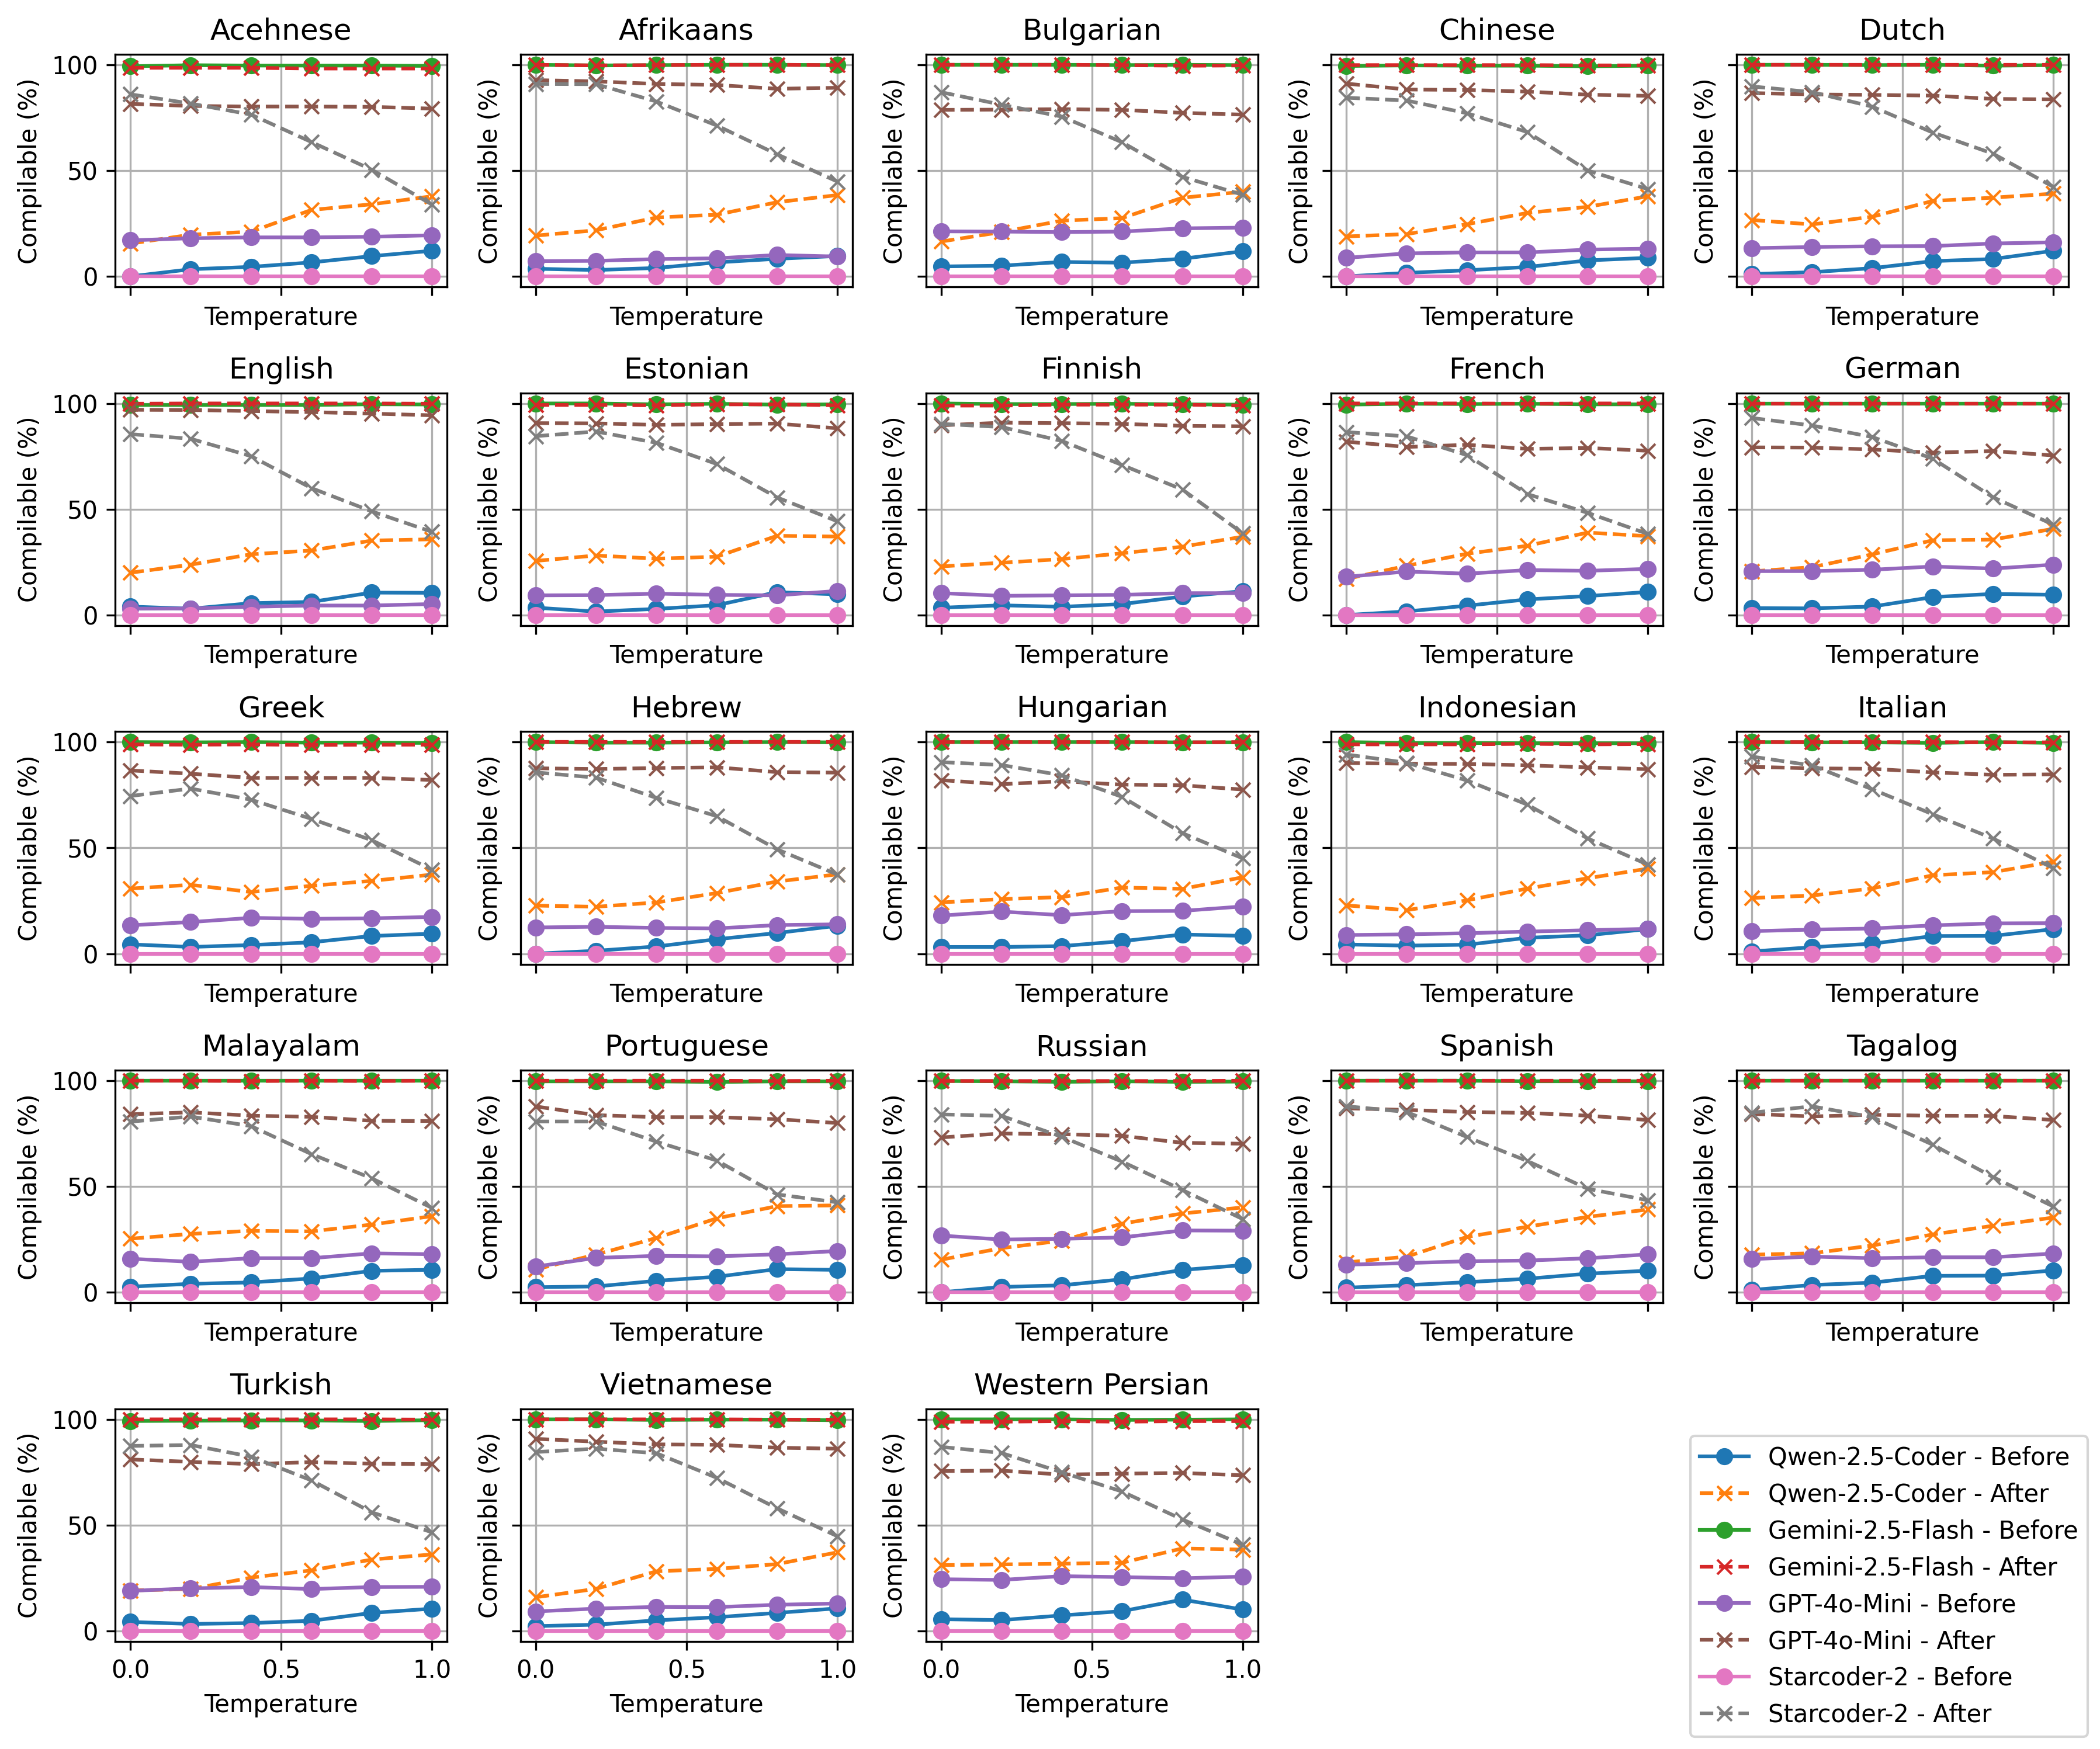

In [20]:
# Load data into a DataFrame
# Since the input is too large to handle manually here, we will simulate a smaller representative sample for demonstration


df = pd.read_csv("../Evaluation/compilation_results_multi.csv")


unique_languages = df['Language'].unique()
num_languages = len(unique_languages)

# Determine the layout of subplots
cols = 5
rows = (num_languages + cols - 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(12, 2 * rows), sharex=True, sharey=True, dpi=300)
axs = axs.flatten()

for idx, language in enumerate(unique_languages):
    ax = axs[idx]
    lang_df = df[df['Language'] == language]
    for model in lang_df['Model'].unique():
        subset = lang_df[lang_df['Model'] == model]
        if "gpt" in model:
            model = "GPT-4o-Mini"
        if "gemini" in model:
            model = "Gemini-2.5-Flash"
        if "Qwen" in model:
            model = "Qwen-2.5-Coder"
        if "starcoder" in model:
            model = "Starcoder-2"
        ax.plot(subset['Temp'], subset['Compilable_before (%)'], marker='o', label=f'{model} - Before')
        ax.plot(subset['Temp'], subset['Compilable_after (%)'], marker='x', linestyle='--', label=f'{model} - After')
    ax.set_title(language)
    ax.set_xlabel('Temperature')
    ax.set_ylabel('Compilable (%)')
    ax.grid(True)

# Add global legend (just once)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', ncol=1, fontsize='medium')

plt.tight_layout(rect=[1, 1, 2, 2])  # leave space at bottom for legend


# Hide any extra subplots
for j in range(idx + 1, len(axs)):
    fig.delaxes(axs[j])

output_path = "./Figure/compilation_results_multi.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300)
